In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [26]:
class Quadstate(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [ ]:
def show_eq(state: Quadstate):
    equation = f'{state['a']}(x^2) + {state['b']}x + {state['c']}'
    return {'equation': equation}

def discriminant(state:  Quadstate):
    disc =state["b"]**2 - (4*state["a"]*state['c'])
    return {'discriminant': disc}


In [ ]:
def real_routes(state: Quadstate):
    r1 = (-state['b'] + state['discriminant']**0.5 )/ (2*state['a'])
    r2 = (-state['b'] - state['discriminant']**0.5 )/ (2*state['a'])
    return  {'result': f'The only two real roots are {r1} and {r2}'}

def repeated_routes(state: Quadstate):
    r = -state['b'] / (2*state['a'])
    return  {'result': f'The only repeating roots are {r}'}

def no_routes(state: Quadstate):
    return  {'result': 'No real routes'}

def check_discriminant(state: Quadstate) -> Literal['real_routes', 'repeated_routes', 'no_routes']:
    if state['discriminant'] > 0:
        return 'real_routes'
    elif state['discriminant'] == 0:
        return 'repeated_routes'
    else:
        return 'no_routes'


In [43]:
graph = StateGraph(Quadstate)

graph.add_node('show_eq', show_eq)
graph.add_node('discriminant', discriminant)
graph.add_node('real_routes', real_routes)
graph.add_node('repeated_routes', repeated_routes)
graph.add_node('no_routes', no_routes)

graph.add_edge(START, 'show_eq')
graph.add_edge('show_eq', 'discriminant')
graph.add_conditional_edges('discriminant', check_discriminant)
graph.add_edge('real_routes', END)
graph.add_edge('repeated_routes', END)
graph.add_edge('no_routes', END)

workflow = graph.compile()


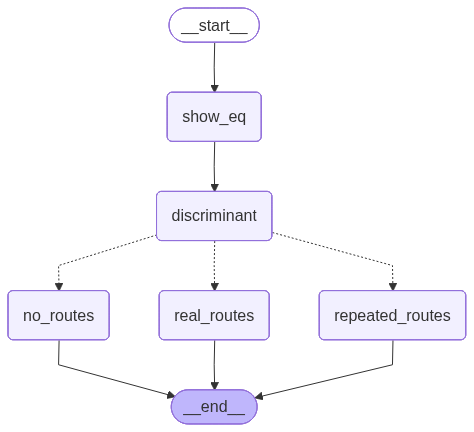

In [44]:
workflow

In [49]:
initial_state = {
    'a': 1, 
    'b': -7,
    'c': 10
}

workflow.invoke(initial_state)

{'a': 1,
 'b': -7,
 'c': 10,
 'equation': '1(x^2) + -7x + 10',
 'discriminant': 9,
 'result': 'The only two real roots are 5.0 and 2.0'}